In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import string
import re
import pymorphy3
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
from nltk.probability import FreqDist

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/3b703cd6-2481-4285-bdc3-
[nltk_data]     8bea7b95bc92/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

In [3]:
#pip install wordcloud

In [4]:
#pip install pymorphy3

In [5]:
file = open('Kazan.txt', 'r')
text = file.read()
file.close()

# 1. Предварительная обработка текста

In [6]:
#1.Разделение слов по пробелу
words = text.split()
print(words[:100])

['XVI', 'Саммит', 'БРИКС', 'Казанская', 'декларация', 'Укрепление', 'многосторонности', 'для', 'справедливого', 'глобального', 'развития', 'и', 'безопасности', 'Казань,', 'Российская', 'Федерация', '23', 'октября', '2024', 'года', '1.', 'Мы,', 'главы', 'государств', 'и', 'правительств', 'стран', 'БРИКС,', 'встретились', 'в', 'Казани,', 'Российская', 'Федерация,', '22', '‑', '24', 'октября', '2024', 'года', 'на', 'XVI', 'саммите', 'БРИКС,', 'посвященном', 'теме:', '«Укрепление', 'многосторонности', 'для', 'справедливого', 'глобального', 'развития', 'и', 'безопасности».', '2.', 'Мы', 'вновь', 'заявляем', 'о', 'важности', 'дальнейшего', 'укрепления', 'солидарности', 'и', 'расширения', 'сотрудничества', 'стран', 'БРИКС', 'на', 'основе', 'наших', 'общих', 'интересов', 'и', 'ключевых', 'приоритетов', 'идальнейшего', 'наращивания', 'нашего', 'стратегического', 'партнерства.', '3.', 'Мы', 'подтверждаем', 'приверженность', 'духу', 'БРИКС,', 'в', 'основе', 'которого', 'взаимоуважение', 'и', 'вза

In [7]:
#2.Удаляем знаки препинания
print(string.punctuation)

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [8]:
re_punc = re.compile('[%s]'%re.escape(string.punctuation))

In [9]:
stripped = [re_punc.sub('', w) for w in words]
print(stripped[:100])

['XVI', 'Саммит', 'БРИКС', 'Казанская', 'декларация', 'Укрепление', 'многосторонности', 'для', 'справедливого', 'глобального', 'развития', 'и', 'безопасности', 'Казань', 'Российская', 'Федерация', '23', 'октября', '2024', 'года', '1', 'Мы', 'главы', 'государств', 'и', 'правительств', 'стран', 'БРИКС', 'встретились', 'в', 'Казани', 'Российская', 'Федерация', '22', '‑', '24', 'октября', '2024', 'года', 'на', 'XVI', 'саммите', 'БРИКС', 'посвященном', 'теме', '«Укрепление', 'многосторонности', 'для', 'справедливого', 'глобального', 'развития', 'и', 'безопасности»', '2', 'Мы', 'вновь', 'заявляем', 'о', 'важности', 'дальнейшего', 'укрепления', 'солидарности', 'и', 'расширения', 'сотрудничества', 'стран', 'БРИКС', 'на', 'основе', 'наших', 'общих', 'интересов', 'и', 'ключевых', 'приоритетов', 'идальнейшего', 'наращивания', 'нашего', 'стратегического', 'партнерства', '3', 'Мы', 'подтверждаем', 'приверженность', 'духу', 'БРИКС', 'в', 'основе', 'которого', 'взаимоуважение', 'и', 'взаимопонимание'

In [10]:
#3. Приведение всех символов к нижнему регистру
tokens = [word.lower() for word in stripped]
print(tokens[:100])

['xvi', 'саммит', 'брикс', 'казанская', 'декларация', 'укрепление', 'многосторонности', 'для', 'справедливого', 'глобального', 'развития', 'и', 'безопасности', 'казань', 'российская', 'федерация', '23', 'октября', '2024', 'года', '1', 'мы', 'главы', 'государств', 'и', 'правительств', 'стран', 'брикс', 'встретились', 'в', 'казани', 'российская', 'федерация', '22', '‑', '24', 'октября', '2024', 'года', 'на', 'xvi', 'саммите', 'брикс', 'посвященном', 'теме', '«укрепление', 'многосторонности', 'для', 'справедливого', 'глобального', 'развития', 'и', 'безопасности»', '2', 'мы', 'вновь', 'заявляем', 'о', 'важности', 'дальнейшего', 'укрепления', 'солидарности', 'и', 'расширения', 'сотрудничества', 'стран', 'брикс', 'на', 'основе', 'наших', 'общих', 'интересов', 'и', 'ключевых', 'приоритетов', 'идальнейшего', 'наращивания', 'нашего', 'стратегического', 'партнерства', '3', 'мы', 'подтверждаем', 'приверженность', 'духу', 'брикс', 'в', 'основе', 'которого', 'взаимоуважение', 'и', 'взаимопонимание'

In [11]:
#4 Удаление токенов, которые не являются буквами
tokens = [word for word in tokens if word.isalpha()]
print(tokens[:100])

['xvi', 'саммит', 'брикс', 'казанская', 'декларация', 'укрепление', 'многосторонности', 'для', 'справедливого', 'глобального', 'развития', 'и', 'безопасности', 'казань', 'российская', 'федерация', 'октября', 'года', 'мы', 'главы', 'государств', 'и', 'правительств', 'стран', 'брикс', 'встретились', 'в', 'казани', 'российская', 'федерация', 'октября', 'года', 'на', 'xvi', 'саммите', 'брикс', 'посвященном', 'теме', 'многосторонности', 'для', 'справедливого', 'глобального', 'развития', 'и', 'мы', 'вновь', 'заявляем', 'о', 'важности', 'дальнейшего', 'укрепления', 'солидарности', 'и', 'расширения', 'сотрудничества', 'стран', 'брикс', 'на', 'основе', 'наших', 'общих', 'интересов', 'и', 'ключевых', 'приоритетов', 'идальнейшего', 'наращивания', 'нашего', 'стратегического', 'партнерства', 'мы', 'подтверждаем', 'приверженность', 'духу', 'брикс', 'в', 'основе', 'которого', 'взаимоуважение', 'и', 'взаимопонимание', 'суверенное', 'равенство', 'солидарность', 'демократия', 'открытость', 'инклюзивност

In [12]:
#5. Удаление стоп-слов
stop_words = stopwords.words('russian')

In [13]:
tokens = [word for word in tokens if not word in stop_words]
print(tokens[:100])

['xvi', 'саммит', 'брикс', 'казанская', 'декларация', 'укрепление', 'многосторонности', 'справедливого', 'глобального', 'развития', 'безопасности', 'казань', 'российская', 'федерация', 'октября', 'года', 'главы', 'государств', 'правительств', 'стран', 'брикс', 'встретились', 'казани', 'российская', 'федерация', 'октября', 'года', 'xvi', 'саммите', 'брикс', 'посвященном', 'теме', 'многосторонности', 'справедливого', 'глобального', 'развития', 'вновь', 'заявляем', 'важности', 'дальнейшего', 'укрепления', 'солидарности', 'расширения', 'сотрудничества', 'стран', 'брикс', 'основе', 'наших', 'общих', 'интересов', 'ключевых', 'приоритетов', 'идальнейшего', 'наращивания', 'нашего', 'стратегического', 'партнерства', 'подтверждаем', 'приверженность', 'духу', 'брикс', 'основе', 'которого', 'взаимоуважение', 'взаимопонимание', 'суверенное', 'равенство', 'солидарность', 'демократия', 'открытость', 'инклюзивность', 'взаимодействие', 'консенсус', 'развитие', 'опыта', 'проведения', 'саммитов', 'брикс'

In [14]:
#6.1 Стемминг
stemmer = SnowballStemmer (language = 'russian')
snow_stemmer = [stemmer.stem(word) for word in tokens]
print(snow_stemmer[:100])

['xvi', 'самм', 'брикс', 'казанск', 'декларац', 'укреплен', 'многосторон', 'справедлив', 'глобальн', 'развит', 'безопасн', 'казан', 'российск', 'федерац', 'октябр', 'год', 'глав', 'государств', 'правительств', 'стран', 'брикс', 'встрет', 'казан', 'российск', 'федерац', 'октябр', 'год', 'xvi', 'самм', 'брикс', 'посвящен', 'тем', 'многосторон', 'справедлив', 'глобальн', 'развит', 'внов', 'заявля', 'важност', 'дальн', 'укреплен', 'солидарн', 'расширен', 'сотрудничеств', 'стран', 'брикс', 'основ', 'наш', 'общ', 'интерес', 'ключев', 'приоритет', 'идальн', 'наращиван', 'наш', 'стратегическ', 'партнерств', 'подтвержда', 'привержен', 'дух', 'брикс', 'основ', 'котор', 'взаимоуважен', 'взаимопониман', 'суверен', 'равенств', 'солидарн', 'демократ', 'открыт', 'инклюзивн', 'взаимодейств', 'консенсус', 'развит', 'опыт', 'проведен', 'саммит', 'брикс', 'приверж', 'дальн', 'углублен', 'сотрудничеств', 'рамк', 'расшир', 'брикс', 'трем', 'магистральн', 'направлен', 'политик', 'безопасн', 'экономик', 'фин

In [15]:
#6.2 Лемматизация
morph = pymorphy3.MorphAnalyzer()

In [16]:
tokens = [morph.parse(word)[0].normal_form for word in tokens]
print(tokens[:100])

['xvi', 'саммит', 'брикс', 'казанский', 'декларация', 'укрепление', 'многосторонность', 'справедливый', 'глобальный', 'развитие', 'безопасность', 'казань', 'российский', 'федерация', 'октябрь', 'год', 'глава', 'государство', 'правительство', 'страна', 'брикс', 'встретиться', 'казань', 'российский', 'федерация', 'октябрь', 'год', 'xvi', 'саммит', 'брикс', 'посвятить', 'тема', 'многосторонность', 'справедливый', 'глобальный', 'развитие', 'вновь', 'заявлять', 'важность', 'дальнейший', 'укрепление', 'солидарность', 'расширение', 'сотрудничество', 'страна', 'брикс', 'основа', 'наш', 'общий', 'интерес', 'ключевой', 'приоритет', 'идальнейший', 'наращивание', 'наш', 'стратегический', 'партнёрство', 'подтверждать', 'приверженность', 'дух', 'брикс', 'основа', 'который', 'взаимоуважение', 'взаимопонимание', 'суверенный', 'равенство', 'солидарность', 'демократия', 'открытость', 'инклюзивность', 'взаимодействие', 'консенсус', 'развитие', 'опыт', 'проведение', 'саммит', 'брикс', 'приверженный', 'дал

In [17]:
#Удаление слишком коротких токенов
tokens = [word for word in tokens if len(word)>3]
print(tokens[:100])

['саммит', 'брикс', 'казанский', 'декларация', 'укрепление', 'многосторонность', 'справедливый', 'глобальный', 'развитие', 'безопасность', 'казань', 'российский', 'федерация', 'октябрь', 'глава', 'государство', 'правительство', 'страна', 'брикс', 'встретиться', 'казань', 'российский', 'федерация', 'октябрь', 'саммит', 'брикс', 'посвятить', 'тема', 'многосторонность', 'справедливый', 'глобальный', 'развитие', 'вновь', 'заявлять', 'важность', 'дальнейший', 'укрепление', 'солидарность', 'расширение', 'сотрудничество', 'страна', 'брикс', 'основа', 'общий', 'интерес', 'ключевой', 'приоритет', 'идальнейший', 'наращивание', 'стратегический', 'партнёрство', 'подтверждать', 'приверженность', 'брикс', 'основа', 'который', 'взаимоуважение', 'взаимопонимание', 'суверенный', 'равенство', 'солидарность', 'демократия', 'открытость', 'инклюзивность', 'взаимодействие', 'консенсус', 'развитие', 'опыт', 'проведение', 'саммит', 'брикс', 'приверженный', 'дальнейший', 'углубление', 'сотрудничество', 'рамка'

# 2. Разведочный анализ данных

In [18]:
all_tokens = FreqDist(tokens)

In [19]:
print (f'Наиболее популярные слова: {all_tokens.most_common(100)}')
print(f'\nОбщее количество уникальных слов: {len(all_tokens.keys())}')

Наиболее популярные слова: [('брикс', 236), ('страна', 165), ('развитие', 113), ('сотрудничество', 109), ('международный', 85), ('также', 80), ('область', 73), ('приветствовать', 60), ('цель', 55), ('подчёркивать', 54), ('призывать', 53), ('сфера', 49), ('устойчивый', 48), ('включая', 48), ('укрепление', 47), ('безопасность', 46), ('обеспечение', 46), ('признать', 46), ('отмечать', 44), ('создание', 44), ('глобальный', 43), ('который', 42), ('роль', 41), ('число', 41), ('государство', 40), ('вопрос', 40), ('связь', 39), ('рамка', 37), ('использование', 37), ('дальнейший', 36), ('система', 36), ('усилие', 36), ('проведение', 35), ('необходимость', 35), ('национальный', 35), ('важность', 34), ('право', 31), ('справедливый', 30), ('решение', 30), ('мера', 30), ('обмен', 30), ('основа', 28), ('экономический', 28), ('потенциал', 28), ('принцип', 28), ('уровень', 28), ('важный', 28), ('вновь', 27), ('расширение', 27), ('подтверждать', 27), ('развивающийся', 27), ('поддерживать', 27), ('подде

/tmp/ipykernel_1707/274647675.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)


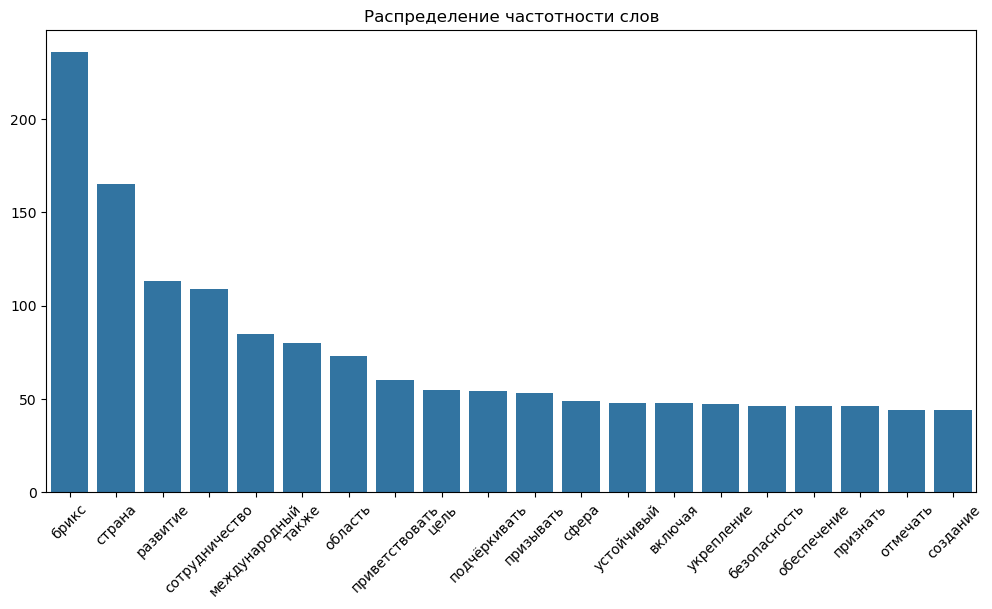

In [20]:
count, words = [],[]
for word in all_tokens.most_common(20):
    words.append(word[0])
    count.append(word[1])
fig,ax = plt.subplots(figsize = (12,6))
ax = sns.barplot(x = words, y = count)
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)
ax.set_title('Распределение частотности слов')
plt.show()

In [21]:
textt = ','.join(word for word in tokens)

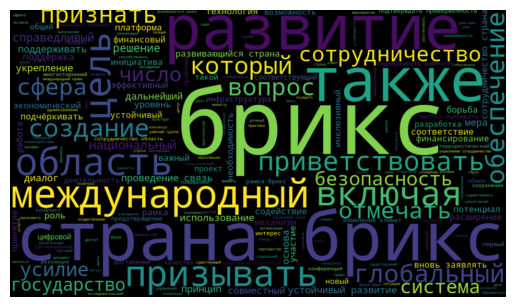

In [22]:
wordcloud = WordCloud (width = 950, height = 550).generate(textt)
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

# 3. Удаление дополнительных стоп-слов (при необходимости)

In [23]:
stop_words_ex = ['брикс','страна','также']

In [24]:
tokens = [word for word in tokens if not word in stop_words_ex]
print(tokens[:100])

['саммит', 'казанский', 'декларация', 'укрепление', 'многосторонность', 'справедливый', 'глобальный', 'развитие', 'безопасность', 'казань', 'российский', 'федерация', 'октябрь', 'глава', 'государство', 'правительство', 'встретиться', 'казань', 'российский', 'федерация', 'октябрь', 'саммит', 'посвятить', 'тема', 'многосторонность', 'справедливый', 'глобальный', 'развитие', 'вновь', 'заявлять', 'важность', 'дальнейший', 'укрепление', 'солидарность', 'расширение', 'сотрудничество', 'основа', 'общий', 'интерес', 'ключевой', 'приоритет', 'идальнейший', 'наращивание', 'стратегический', 'партнёрство', 'подтверждать', 'приверженность', 'основа', 'который', 'взаимоуважение', 'взаимопонимание', 'суверенный', 'равенство', 'солидарность', 'демократия', 'открытость', 'инклюзивность', 'взаимодействие', 'консенсус', 'развитие', 'опыт', 'проведение', 'саммит', 'приверженный', 'дальнейший', 'углубление', 'сотрудничество', 'рамка', 'расшириться', 'магистральный', 'направление', 'политика', 'безопасность

# 4. Повторный разведочный анализ

In [25]:
all_tokens = FreqDist(tokens)

In [26]:
print (f'Наиболее популярные слова: {all_tokens.most_common(100)}')
print(f'\nОбщее количество уникальных слов: {len(all_tokens.keys())}')

Наиболее популярные слова: [('развитие', 113), ('сотрудничество', 109), ('международный', 85), ('область', 73), ('приветствовать', 60), ('цель', 55), ('подчёркивать', 54), ('призывать', 53), ('сфера', 49), ('устойчивый', 48), ('включая', 48), ('укрепление', 47), ('безопасность', 46), ('обеспечение', 46), ('признать', 46), ('отмечать', 44), ('создание', 44), ('глобальный', 43), ('который', 42), ('роль', 41), ('число', 41), ('государство', 40), ('вопрос', 40), ('связь', 39), ('рамка', 37), ('использование', 37), ('дальнейший', 36), ('система', 36), ('усилие', 36), ('проведение', 35), ('необходимость', 35), ('национальный', 35), ('важность', 34), ('право', 31), ('справедливый', 30), ('решение', 30), ('мера', 30), ('обмен', 30), ('основа', 28), ('экономический', 28), ('потенциал', 28), ('принцип', 28), ('уровень', 28), ('важный', 28), ('вновь', 27), ('расширение', 27), ('подтверждать', 27), ('развивающийся', 27), ('поддерживать', 27), ('поддержка', 27), ('борьба', 27), ('совместный', 26), 

/tmp/ipykernel_1707/274647675.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)


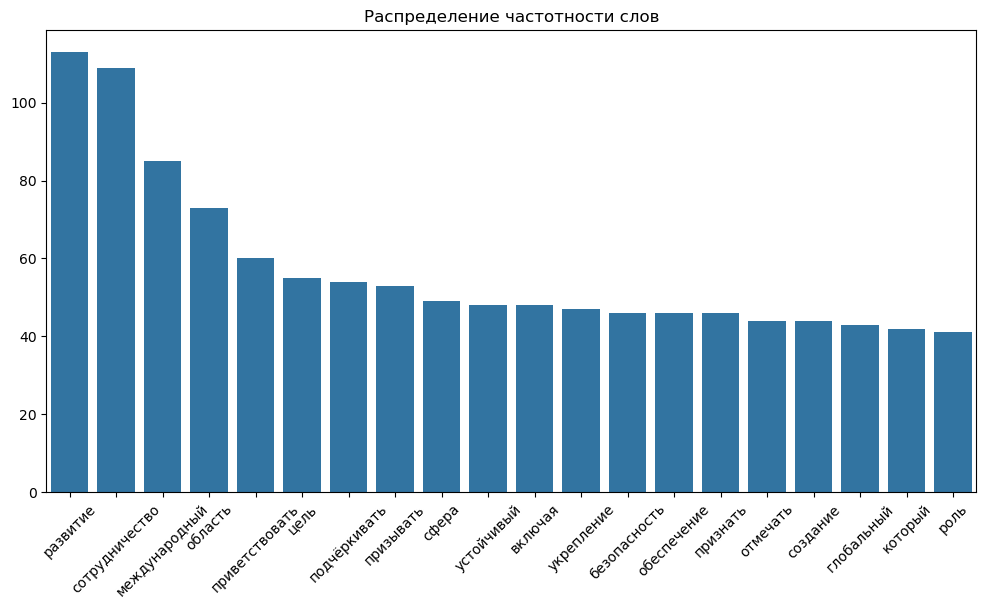

In [27]:
count, words = [],[]
for word in all_tokens.most_common(20):
    words.append(word[0])
    count.append(word[1])
fig,ax = plt.subplots(figsize = (12,6))
ax = sns.barplot(x = words, y = count)
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45)
ax.set_title('Распределение частотности слов')
plt.show()

In [28]:
textt = ','.join(word for word in tokens)

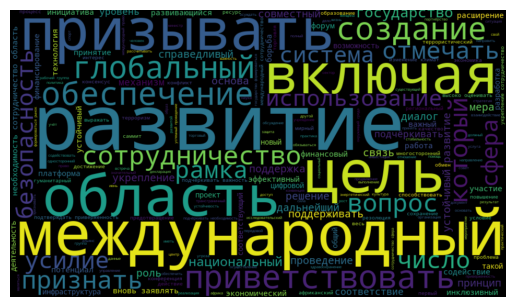

In [29]:
wordcloud = WordCloud (width = 950, height = 550).generate(textt)
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

# 5. Векторизация слов

In [30]:
#5.1
count_vect = CountVectorizer (max_df= 0.8, min_df = 3, stop_words = None)

In [31]:
doc_term_matrix = count_vect.fit_transform(tokens)

In [32]:
doc_term_matrix

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 6552 stored elements and shape (8058, 672)>

In [33]:
#5.2
tfidf_vect = TfidfVectorizer(max_df = 1.0, min_df = 2, stop_words = None)

In [34]:
doc_term_matrix = tfidf_vect.fit_transform(tokens)

In [35]:
doc_term_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7140 stored elements and shape (8058, 966)>

# 6. Тематическое моделирование

In [36]:
#6.1. Латентное размещение Дерихле

In [37]:
LDA = LatentDirichletAllocation (n_components = 2, random_state = 42)
LDA.fit(doc_term_matrix)

,n_components,2
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [38]:
LDA.components_

array([[ 0.5236394 ,  2.4789487 ,  3.47930055, ...,  4.47948778,
        11.47986624,  0.52267671],
       [ 2.4763606 ,  0.5210513 ,  0.52069945, ...,  0.52051222,
         0.52013376,  6.47732329]])

In [43]:
for i, topic in enumerate(LDA.components_):
    print (f'Top 10 words for topic # {i}: ')
    print ([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print()

Top 10 words for topic # 0: 
['вопрос', 'глобальный', 'признать', 'безопасность', 'сфера', 'подчёркивать', 'цель', 'приветствовать', 'область', 'международный']

Top 10 words for topic # 1: 
['который', 'отмечать', 'создание', 'обеспечение', 'укрепление', 'включая', 'устойчивый', 'призывать', 'сотрудничество', 'развитие']



In [44]:
LDA = LatentDirichletAllocation (n_components = 3, random_state = 42)
LDA.fit(doc_term_matrix)

,n_components,3
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [45]:
for i, topic in enumerate(LDA.components_):
    print (f'Top 10 words for topic # {i}: ')
    print ([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print()

Top 10 words for topic # 0: 
['проведение', 'дальнейший', 'связь', 'вопрос', 'глобальный', 'сфера', 'подчёркивать', 'цель', 'приветствовать', 'область']

Top 10 words for topic # 1: 
['рамка', 'число', 'роль', 'создание', 'обеспечение', 'включая', 'устойчивый', 'призывать', 'сотрудничество', 'развитие']

Top 10 words for topic # 2: 
['система', 'усилие', 'использование', 'государство', 'который', 'отмечать', 'безопасность', 'признать', 'укрепление', 'международный']



In [46]:
LDA = LatentDirichletAllocation (n_components = 4, random_state = 42)
LDA.fit(doc_term_matrix)

,n_components,4
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [47]:
for i, topic in enumerate(LDA.components_):
    print (f'Top 10 words for topic # {i}: ')
    print ([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print()

Top 10 words for topic # 0: 
['обмен', 'проведение', 'связь', 'вопрос', 'глобальный', 'сфера', 'подчёркивать', 'цель', 'приветствовать', 'область']

Top 10 words for topic # 1: 
['расширение', 'потенциал', 'экономический', 'право', 'необходимость', 'рамка', 'число', 'роль', 'сотрудничество', 'развитие']

Top 10 words for topic # 2: 
['важность', 'национальный', 'система', 'использование', 'государство', 'который', 'отмечать', 'признать', 'безопасность', 'международный']

Top 10 words for topic # 3: 
['справедливый', 'мера', 'дальнейший', 'усилие', 'создание', 'обеспечение', 'укрепление', 'устойчивый', 'включая', 'призывать']



In [49]:
LDA = LatentDirichletAllocation (n_components = 5, random_state = 42)
LDA.fit(doc_term_matrix)

,n_components,5
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [50]:
for i, topic in enumerate(LDA.components_):
    print (f'Top 10 words for topic # {i}: ')
    print ([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print()

Top 10 words for topic # 0: 
['рынок', 'подтверждать', 'принцип', 'обмен', 'связь', 'глобальный', 'сфера', 'подчёркивать', 'цель', 'приветствовать']

Top 10 words for topic # 1: 
['приверженность', 'вновь', 'поддерживать', 'экономический', 'потенциал', 'необходимость', 'роль', 'число', 'сотрудничество', 'развитие']

Top 10 words for topic # 2: 
['климат', 'работа', 'диалог', 'технология', 'поддержка', 'уровень', 'национальный', 'использование', 'который', 'международный']

Top 10 words for topic # 3: 
['основа', 'мера', 'усилие', 'дальнейший', 'создание', 'обеспечение', 'укрепление', 'включая', 'устойчивый', 'призывать']

Top 10 words for topic # 4: 
['важность', 'проведение', 'система', 'рамка', 'государство', 'вопрос', 'отмечать', 'безопасность', 'признать', 'область']



In [52]:
#6.2. Неотрицательная матричная факторизация
nmf = NMF (n_components = 2, random_state = 42)
nmf.fit(doc_term_matrix)

,n_components,2
,init,None
,solver,'cd'
,beta_loss,'frobenius'
,tol,0.0001
,max_iter,200
,random_state,42
,alpha_W,0.0
,alpha_H,'same'
,l1_ratio,0.0
,verbose,0


In [54]:
for i, topic in enumerate(nmf.components_):
    print(f'Top 10 words for topic #{i}: ')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort ()[-10:]]) 
    print()

Top 10 words for topic #0: 
['признать', 'безопасность', 'цель', 'обеспечение', 'укрепление', 'подчёркивать', 'область', 'приветствовать', 'международный', 'развитие']

Top 10 words for topic #1: 
['включая', 'создание', 'сфера', 'укрепление', 'подчёркивать', 'цель', 'приветствовать', 'область', 'международный', 'сотрудничество']



In [55]:
nmf = NMF (n_components = 5, random_state = 42)
nmf.fit(doc_term_matrix)

,n_components,5
,init,None
,solver,'cd'
,beta_loss,'frobenius'
,tol,0.0001
,max_iter,200
,random_state,42
,alpha_W,0.0
,alpha_H,'same'
,l1_ratio,0.0
,verbose,0


In [56]:
for i, topic in enumerate(nmf.components_):
    print(f'Top 10 words for topic #{i}: ')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort ()[-10:]]) 
    print()

Top 10 words for topic #0: 
['создание', 'признать', 'устойчивый', 'безопасность', 'подчёркивать', 'включая', 'сфера', 'цель', 'призывать', 'развитие']

Top 10 words for topic #1: 
['признать', 'безопасность', 'обеспечение', 'укрепление', 'включая', 'сфера', 'подчёркивать', 'призывать', 'цель', 'сотрудничество']

Top 10 words for topic #2: 
['укрепление', 'отмечать', 'создание', 'включая', 'устойчивый', 'сфера', 'подчёркивать', 'цель', 'призывать', 'международный']

Top 10 words for topic #3: 
['отмечать', 'включая', 'укрепление', 'безопасность', 'подчёркивать', 'устойчивый', 'сфера', 'цель', 'призывать', 'область']

Top 10 words for topic #4: 
['устойчивый', 'включая', 'глобальный', 'сфера', 'безопасность', 'призывать', 'признать', 'цель', 'подчёркивать', 'приветствовать']

